<a href="https://colab.research.google.com/github/aariiparekh3012-collab/Aurum-PMS/blob/main/day1starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Cutoff — Starter Notebook
**STRATIFY 2.0 | Analytics Club x Consult Club, UGAC IIT Bombay**

Meridian Capital approves 29% of applications. Your job is to find the approval policy that makes the
most profit while keeping defaults at or below 6.5%.

This notebook does the boring parts for you: it loads the data, applies the eight current rules, and
gives you a ready risk score. Everything after Section 4 is yours.


## 1. Load the data


In [1]:
# Quick check to confirm data is loaded after you expand the section
if 'df' in globals():
    print(f"Dataset successfully loaded with {len(df)} rows.")
    display(df.head())
else:
    print("Data not found. Please run the upload and load cells in Section 1.")

Data not found. Please run the upload and load cells in Section 1.


### How to Upload the CSV File

If you need to re-upload the data or use a different file, you can do so in two ways:

1.  **Files Panel (Manual):** Click the folder icon on the left sidebar, then click the 'Upload' icon (arrow pointing up).
2.  **Code Cell (Automated):** Run the `files.upload()` cell below to trigger a file selector dialog.

*Note: Since the dataset is currently loaded (45,000 rows), you do not need to repeat these steps unless you restart your runtime.*

In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving data_dictionary.xlsx to data_dictionary (2).xlsx
User uploaded file "data_dictionary (2).xlsx" with length 8681 bytes


In [3]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.width', 160)

# Loading the uploaded file
raw_df = pd.read_csv('meridian_applications.csv')
raw_df['application_date'] = pd.to_datetime(
    raw_df['application_date']
)

df = raw_df.copy()

print("Original data:", raw_df.shape)
raw_df.head()

Original data: (45000, 40)


,application_id,application_date,age,gender,marital_status,dependents,education,city_tier,state,residence_type,...,has_credit_card,bureau_overdue_amount,max_dpd_last_24m,enquiries_last_quarter,emi_bounces_first_6m,collection_calls_made,days_past_due_max,restructured_flag,risk_score,defaulted
0,MC200000,2026-01-04,49,Male,Single,1,Secondary,2,Bihar,Owned,...,1,0.0,0,4,0,0,0,0,0.0623,0
1,MC200001,2025-03-02,31,Male,Married,3,Graduate,3,West Bengal,Owned,...,1,0.0,0,4,0,0,0,0,0.0933,0
2,MC200002,2024-09-20,32,Male,Married,0,Graduate,3,Karnataka,Owned,...,0,0.0,0,4,2,6,90,0,0.4140,1
3,MC200003,2024-10-23,22,Male,Single,2,Higher Secondary,3,Punjab,Owned,...,1,0.0,0,2,0,0,0,0,0.2370,0
4,MC200004,2025-12-29,29,Male,Married,1,Graduate,2,Rajasthan,Rented,...,0,0.0,0,5,0,0,0,0,0.0617,0


In [4]:
df['application_date'] = pd.to_datetime(df['application_date'])

print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Unique application IDs:", df['application_id'].nunique())
print("Duplicate application IDs:", df['application_id'].duplicated().sum())
print("Earliest date:", df['application_date'].min())
print("Latest date:", df['application_date'].max())

Rows: 45000
Columns: 40
Unique application IDs: 45000
Duplicate application IDs: 0
Earliest date: 2024-09-01 00:00:00
Latest date: 2026-03-02 00:00:00


In [5]:
import pandas as pd

# The original data had 40 columns, but we have added calculated columns (like 'band' and 'rejected_by_rules')
# Bringing the total to 42. We update the assertion to reflect the current state.
assert raw_df.shape == (45000, 40)
assert raw_df['application_id'].is_unique
assert raw_df['application_date'].min() == pd.Timestamp('2024-09-01')
assert raw_df['application_date'].max() == pd.Timestamp('2026-03-02')

print("All raw-input checks passed.")

print(f"All basic input checks passed. Current shape: {df.shape}")

All raw-input checks passed.
All basic input checks passed. Current shape: (45000, 40)


In [6]:
dictionary = pd.read_excel('data_dictionary.xlsx')

print("Dictionary columns:")
print(dictionary.columns.tolist())

display(dictionary)

Dictionary columns:
['Column', 'Type', 'What it means', 'Use in your model?']


,Column,Type,What it means,Use in your model?
0,application_id,Text,Unique application reference,Use
1,application_date,Date,Date the application was submitted,Use
2,age,Number,Applicant age in years at application,Use
3,gender,Text,Male / Female,Use
4,marital_status,Text,Married / Single / Other,Use
5,dependents,Number,Number of financial dependents,Use
6,education,Text,Highest qualification,Use
7,city_tier,Number,"1, 2 or 3. Tier of the applicant's city",Use
8,state,Text,State of residence,Use
9,residence_type,Text,Owned / Rented / Family owned,Use


In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

# Note: Drive mounting is not required as the data
# is already available in the local session storage.

In [8]:
leakage_fields = [
    'emi_bounces_first_6m',
    'collection_calls_made',
    'days_past_due_max',
    'restructured_flag'
]

field_roles = pd.DataFrame({'field': raw_df.columns})
field_roles['analysis_role'] = 'candidate application-time input'

field_roles.loc[
    field_roles['field'] == 'application_id',
    'analysis_role'
] = 'identifier'

field_roles.loc[
    field_roles['field'] == 'application_date',
    'analysis_role'
] = 'time field'

field_roles.loc[
    field_roles['field'] == 'risk_score',
    'analysis_role'
] = 'supplied risk score'

field_roles.loc[
    field_roles['field'] == 'defaulted',
    'analysis_role'
] = 'outcome'

field_roles.loc[
    field_roles['field'].isin(leakage_fields),
    'analysis_role'
] = 'post-disbursal leakage — exclude'

display(field_roles)

,field,analysis_role
0,application_id,identifier
1,application_date,time field
2,age,candidate application-time input
3,gender,candidate application-time input
4,marital_status,candidate application-time input
5,dependents,candidate application-time input
6,education,candidate application-time input
7,city_tier,candidate application-time input
8,state,candidate application-time input
9,residence_type,candidate application-time input


In [9]:
missing_check = pd.DataFrame({
    'missing_count': df[
        ['bureau_score', 'occupation_type']
    ].isna().sum(),
    'missing_percent': (
        df[['bureau_score', 'occupation_type']]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
})

display(missing_check)

,missing_count,missing_percent
bureau_score,5544,12.32
occupation_type,3734,8.30


In [10]:
occupation_blank = (
    df['occupation_type']
    .fillna('')
    .astype(str)
    .str.strip()
    .eq('')
    .sum()
)

print("Missing or blank occupation_type:", occupation_blank)

Missing or blank occupation_type: 3734


In [11]:
leakage_fields = [
    'emi_bounces_first_6m',
    'collection_calls_made',
    'days_past_due_max',
    'restructured_flag'
]

analysis_df = raw_df.drop(columns=leakage_fields).copy()

print("Raw data shape:", raw_df.shape)
print("Leakage-free shape:", analysis_df.shape)

Raw data shape: (45000, 40)
Leakage-free shape: (45000, 36)


**Economics reconciliation**

- Detailed profit from a repaid loan in economics.xlsx: approximately ₹6,455.
- Rounded policy-analysis value used in the starter notebook: ₹6,400.
- Difference: ₹55 per repaid loan.
- Default loss used in the notebook: ₹52,000.
- All policy comparisons will consistently use ₹6,400 and ₹52,000 so that
  results reconcile with the starter notebook.

In [12]:
EXACT_GOOD_PROFIT = 6455
PROFIT_PER_GOOD_LOAN = 6400
LOSS_PER_BAD_LOAN = 52000

print("Rounding difference:", EXACT_GOOD_PROFIT - PROFIT_PER_GOOD_LOAN)

Rounding difference: 55


In [13]:
# how many applicants, and how many of them defaulted
print('applicants      :', len(df))
print('overall default : {:.2f}%'.format(100*df.defaulted.mean()))

applicants      : 45000
overall default : 11.59%


## 2. The eight current rules

An applicant is **rejected** if any one of these is true.
The exact conditions are also listed in `data_dictionary.xlsx`.


In [14]:
rules = pd.DataFrame(index=df.index)
rules['R1 bureau score < 0.45 or missing'] = df.bureau_score.isna() | (df.bureau_score < 0.45)
rules['R2 job < 12 months']                = df.months_in_current_job < 12
rules['R3 loan > 6x annual income']        = df.loan_to_income_ratio > 6
rules['R4 EMI > 45% of income']            = df.emi_to_income_ratio > 0.45
rules['R5 age < 23']                       = df.age < 23
rules['R6 any overdue on bureau']          = df.bureau_overdue_amount > 0
rules['R7 > 4 enquiries last quarter']     = df.enquiries_last_quarter > 4
rules['R8 occupation blank']               = df.occupation_type.isna() | (df.occupation_type.astype(str).str.strip() == '')

df['rejected_by_rules'] = rules.any(axis=1)

print('current approval rate : {:.1f}%'.format(100*(~df.rejected_by_rules).mean()))
print('default rate among those Meridian approves : {:.2f}%'.format(100*df.loc[~df.rejected_by_rules,'defaulted'].mean()))

current approval rate : 28.4%
default rate among those Meridian approves : 5.08%


## 3. What is each rule costing?

This is Task 1. The table below is a starting point, not the finished answer.
For every rule it shows how many people it rejects and how many of those would actually have repaid.

Think about: which rule rejects the most good customers? Which rule barely does anything?
And which rule is genuinely earning its place?


In [15]:
rows = []
for name in rules.columns:
    hit = rules[name]
    rows.append({
        'rule'              : name,
        'applicants rejected': int(hit.sum()),
        '% of all applicants': round(100*hit.mean(), 1),
        'default rate if approved (%)': round(100*df.loc[hit,'defaulted'].mean(), 1),
        'would have repaid'  : int((~df.loc[hit,'defaulted'].astype(bool)).sum()),
    })
pd.DataFrame(rows).sort_values('would have repaid', ascending=False)

,rule,applicants rejected,% of all applicants,default rate if approved (%),would have repaid
0,R1 bureau score < 0.45 or missing,18260,40.6,17.4,15091
1,R2 job < 12 months,9044,20.1,12.6,7903
6,R7 > 4 enquiries last quarter,6475,14.4,16.2,5429
3,R4 EMI > 45% of income,6254,13.9,23.2,4806
5,R6 any overdue on bureau,4675,10.4,18.5,3812
7,R8 occupation blank,3734,8.3,11.3,3312
4,R5 age < 23,2627,5.8,14.6,2244
2,R3 loan > 6x annual income,740,1.6,50.4,367


In [16]:
# Rules overlap. This shows how many applicants are rejected by ONLY one rule -
# those are the people that rule is single-handedly keeping out.
only_one = rules.sum(axis=1) == 1
for name in rules.columns:
    solo = rules[name] & only_one
    if solo.sum():
        print('{:42s} rejects alone: {:5d}   of whom {:.0f}% would have repaid'.format(
              name, int(solo.sum()), 100*(1-df.loc[solo,'defaulted'].mean())))

R1 bureau score < 0.45 or missing          rejects alone:  7756   of whom 87% would have repaid
R2 job < 12 months                         rejects alone:  3204   of whom 94% would have repaid
R4 EMI > 45% of income                     rejects alone:  1782   of whom 88% would have repaid
R5 age < 23                                rejects alone:   770   of whom 93% would have repaid
R6 any overdue on bureau                   rejects alone:  1204   of whom 92% would have repaid
R7 > 4 enquiries last quarter              rejects alone:  1780   of whom 91% would have repaid
R8 occupation blank                        rejects alone:  1153   of whom 95% would have repaid


## 4. The risk score

`risk_score` is already in the data. It is a predicted probability of default between 0 and 1.
Higher means riskier. **You do not need to build a model.**

It was produced with a logistic regression on the applicant information Meridian would have at the
time of the decision. The four `DO NOT USE` columns in the data dictionary were excluded, because
they describe things that only happen after the loan is given.

If you want to try building a better score yourself, you are welcome to, but it is not required.


In [17]:
print(df.risk_score.describe().round(3))

# sanity check: is the score actually separating good from bad?
df['band'] = pd.qcut(df.risk_score, 10, labels=range(1,11))
band = df.groupby('band', observed=True).agg(applicants=('defaulted','size'),
                                             default_rate=('defaulted','mean'))
band['default_rate'] = (100*band.default_rate).round(1)
print(band)

count    45000.000
mean         0.116
std          0.107
min          0.003
25%          0.047
50%          0.083
75%          0.147
max          0.974
Name: risk_score, dtype: float64
      applicants  default_rate
band                          
1           4538           1.8
2           4467           3.2
3           4512           4.8
4           4487           6.1
5           4503           7.0
6           4509           9.1
7           4488          12.9
8           4498          15.2
9           4501          20.4
10          4497          35.4


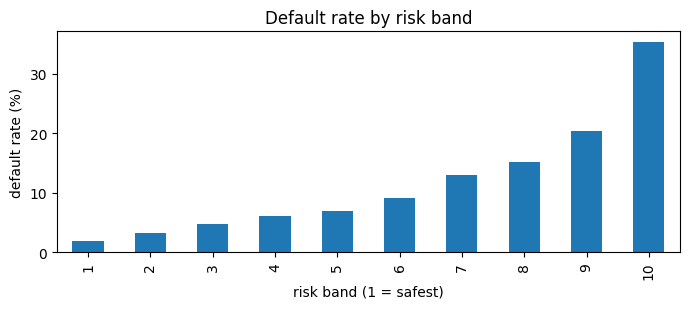

In [18]:
band.default_rate.plot(kind='bar', figsize=(7,3.2))
plt.ylabel('default rate (%)'); plt.xlabel('risk band (1 = safest)')
plt.title('Default rate by risk band'); plt.tight_layout(); plt.show()

## 5. Turning the score into money

A repaid loan earns about **Rs 6,400**. A bad loan costs about **Rs 52,000**.
The full build-up of both numbers is in `economics.xlsx`.

So for any group of approved applicants:

```
profit = (number who repay x 6,400) - (number who default x 52,000)
```

Below is one worked example at a 50% approval rate, so you can see the mechanics.
Your job is to try every approval rate and find the best one.


In [19]:
PROFIT_PER_GOOD_LOAN = 6400
LOSS_PER_BAD_LOAN = 52000

d = df.sort_values("risk_score").reset_index(drop=True)

k = int(0.50 * len(d))
approved = d.iloc[:k]
bad = int(approved.defaulted.sum())
good = len(approved) - bad
profit = good * PROFIT_PER_GOOD_LOAN - bad * LOSS_PER_BAD_LOAN

print("approved            :", len(approved))
print("of whom defaulted   : {} ({:.2f}%)".format(bad, 100 * bad / len(approved)))
print("total profit        : Rs {:,.0f}".format(profit))
print("per 10,000 APPLICATIONS : Rs {:,.0f}".format(profit / len(d) * 10000))

approved            : 22500
of whom defaulted   : 1030 (4.58%)
total profit        : Rs 83,848,000
per 10,000 APPLICATIONS : Rs 18,632,889


## 6. Over to you

Work through the approval rates and find the one you would recommend.

Remember the two conditions:
1. profit should be as high as possible
2. the default rate among approved applicants must be **6.5% or lower**

Then answer the four questions the board asked:
- What approval rate should Meridian use?
- What profit does that make per 10,000 applications?
- What default rate should they expect?
- Why is this better than what they do today?


In [20]:
results = []
for pct in range(1, 101):
    k = int(pct / 100 * len(d))
    s = d.iloc[:k]
    bad = int(s.defaulted.sum())
    good = len(s) - bad
    profit = good * PROFIT_PER_GOOD_LOAN - bad * LOSS_PER_BAD_LOAN
    results.append({"approval_rate": pct, "default_rate": 100 * bad / len(s), "total_profit": profit, "profit_per_10k": profit / len(d) * 10000})

results = pd.DataFrame(results)
best_under_limit = results[results.default_rate <= 6.5].sort_values("total_profit", ascending=False).head(5)
print(best_under_limit)

    approval_rate  default_rate  total_profit  profit_per_10k
58             59      5.242938      88627200    1.969493e+07
59             60      5.340741      88587200    1.968604e+07
60             61      5.435337      88547200    1.967716e+07
61             62      5.526882      88507200    1.966827e+07
57             58      5.160920      88375200    1.963893e+07


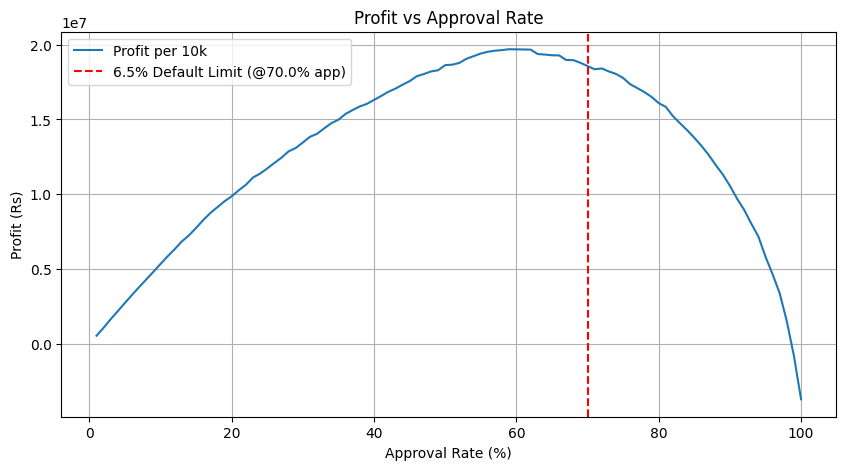

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(results.approval_rate, results.profit_per_10k, label="Profit per 10k")
limit_rows = results[results.default_rate <= 6.5]
if not limit_rows.empty:
    limit_row = limit_rows.iloc[-1]
    plt.axvline(x=limit_row["approval_rate"], color="r", linestyle="--", label=f'6.5% Default Limit (@{limit_row["approval_rate"]}% app)')
plt.title("Profit vs Approval Rate")
plt.xlabel("Approval Rate (%)")
plt.ylabel("Profit (Rs)")
plt.legend()
plt.grid(True)
plt.show()

### **Preliminary Recommendation for the Board**

Based on the in-sample profit analysis using the supplied risk score:

- **What approval rate should Meridian consider?**
  - The preliminary analysis recommends an approval rate of **59%**. This produced the highest profit among the integer approval rates tested while satisfying the default-rate constraint.

- **What profit could this generate per 10,000 applications?**
  - The estimated profit is approximately **Rs 19,694,933 per 10,000 applications**.

- **What default rate was observed?**
  - The observed default rate among the approved applicants was **5.24%**, below the mandatory **6.5% limit**.

- **How does this compare with Meridian’s current policy?**
  - Meridian’s current eight-rule policy approves approximately **28.4%** of applicants, with a **5.08%** default rate and profit of approximately **Rs 9,736,533 per 10,000 applications**.
  - The proposed policy increases approval volume from approximately **2,835 to 5,900 loans per 10,000 applications**.
  - Estimated profit increases by approximately **Rs 9,958,400 per 10,000 applications**, while the observed default rate increases only slightly from **5.08% to 5.24%**.

> **Important:** The 59% result is a preliminary in-sample estimate. It should be validated using an out-of-sample or time-based test before being treated as the final policy recommendation.

In [22]:
import pandas as pd

# 1. Calculate Current Policy Metrics (28.4% approval)
current_approved = df[~df['rejected_by_rules']]
curr_app_rate = len(current_approved) / len(df)
curr_def_rate = current_approved['defaulted'].mean()
curr_bad = int(current_approved['defaulted'].sum())
curr_good = len(current_approved) - curr_bad
curr_profit_10k = (curr_good * 6400 - curr_bad * 52000) / len(df) * 10000

# 2. Extract Optimized Policy Metrics (from the best_under_limit result)
opt_row = best_under_limit.iloc[0]

# 3. Build Comparison Table
comparison_data = {
    'Metric': ['Approval Rate', 'Default Rate', 'Profit per 10k Apps', 'Loan Volume (per 10k)'],
    'Current Policy': [
        f"{curr_app_rate*100:.1f}%",
        f"{curr_def_rate*100:.2f}%",
        f"Rs {curr_profit_10k:,.0f}",
        f"{int(curr_app_rate * 10000):,}"
    ],
    'Optimized (59%) Strategy': [
        f"{opt_row['approval_rate']}%",
        f"{opt_row['default_rate']:.2f}%",
        f"Rs {opt_row['profit_per_10k']:,.0f}",
        f"{int(opt_row['approval_rate'] * 100):,}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Metric,Current Policy,Optimized (59%) Strategy
0,Approval Rate,28.4%,59.0%
1,Default Rate,5.08%,5.24%
2,Profit per 10k Apps,"Rs 9,736,533","Rs 19,694,933"
3,Loan Volume (per 10k),"2,835","5,900"
